### RMS Titanic
**The RMS Titanic was a British passenger liner that sank in the North Atlantic Ocean in the early morning hours of 15 April 1912, after it collided with an iceberg during its maiden voyage from Southampton to New York City. There were an estimated 2,224 passengers and crew aboard the ship, and more than 1,500 died, making it one of the deadliest commercial peacetime maritime disasters in modern history. The RMS Titanic was the largest ship afloat at the time it entered service and was the second of three Olympic-class ocean liners operated by the White Star Line. The Titanic was built by the Harland and Wolff shipyard in Belfast. Thomas Andrews, her architect, died in the disaster.**

### Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load Data

In [2]:
train_df=pd.read_csv('../input/titanic/train.csv')
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_df=pd.read_csv('../input/titanic/test.csv')
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
submit=pd.read_csv('../input/titanic/gender_submission.csv')
submit.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


### Data Information _ Analysis

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [7]:
submit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


In [8]:
titanic_df=pd.concat([train_df,test_df], axis=0)
titanic_df.set_index('PassengerId',inplace=True)

In [9]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
titanic_df.columns


Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 1 to 1309
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    float64
 1   Pclass    1309 non-null   int64  
 2   Name      1309 non-null   object 
 3   Sex       1309 non-null   object 
 4   Age       1046 non-null   float64
 5   SibSp     1309 non-null   int64  
 6   Parch     1309 non-null   int64  
 7   Ticket    1309 non-null   object 
 8   Fare      1308 non-null   float64
 9   Cabin     295 non-null    object 
 10  Embarked  1307 non-null   object 
dtypes: float64(3), int64(3), object(5)
memory usage: 122.7+ KB


### Dealing with the missing data

#### We should some features, that contain missing values (NaN = not a number), that we need to deal with.


 Let’s take a more detailed look at what data is actually missing:

In [12]:
titanic_df.isnull().sum()

Survived     418
Pclass         0
Name           0
Sex            0
Age          263
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin       1014
Embarked       2
dtype: int64

In [13]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [15]:
def missing_percent(df):
    nan_percent= 100*(df.isnull().sum()/len(df))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [16]:
print(missing_percent(titanic_df),'\n')
print(missing_percent(train_df),'\n')
print(missing_percent(test_df),'\n')
    

Fare         0.076394
Embarked     0.152788
Age         20.091673
Survived    31.932773
Cabin       77.463713
dtype: float64 

Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64 

Fare      0.239234
Age      20.574163
Cabin    78.229665
dtype: float64 



#### The **Embarked** feature has only 2 missing values, which can easily be filled. It will be much more tricky, to deal with the **‘Age’** feature, which has 177 missing values. The **‘Cabin’** feature needs further investigation, but it looks like that we might want to drop it from the dataset, since 77 % of it are missing.

## Age

Now we can tackle the issue with the age features missing values. I will create an array that contains random numbers, which are computed based on the mean age value in regards to the standard deviation and is_null.

In [17]:
train_df['Age'].isnull().sum()

177

In [18]:
arr_index=train_df[train_df['Age'].isnull()].index
arr_index

Int64Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
            ...
            832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
           dtype='int64', length=177)

In [19]:
all_data=[train_df,test_df]
for dataset in all_data:
    mean = titanic_df["Age"].mean()
    std = titanic_df["Age"].std()
    dataset_isnull=dataset['Age'].isnull().sum()
    dataset_r_age=np.random.randint(mean - std, mean + std, size = dataset_isnull)

    
    age_slice=dataset['Age'].copy()
    age_slice[np.isnan(age_slice)]=dataset_r_age
    dataset["Age"]=age_slice
    dataset["Age"]=dataset["Age"].astype(int)

In [20]:
print(train_df['Age'].isnull().sum())
print(test_df['Age'].isnull().sum())

0
0


## Embarked

In [21]:
print(titanic_df['Embarked'].describe())
print("\n")
print(titanic_df['Embarked'].value_counts())

count     1307
unique       3
top          S
freq       914
Name: Embarked, dtype: object


S    914
C    270
Q    123
Name: Embarked, dtype: int64


### Embarked feature has only 2 missing values, we will fill these with the most common one.


In [22]:
common_value = 'S'
all_data = [train_df, test_df]

for dataset in all_data:
    dataset['Embarked'] = dataset['Embarked'].fillna(common_value)

In [23]:
print(train_df['Embarked'].isnull().sum())
print(test_df['Embarked'].isnull().sum())

0
0


## Fare

In [24]:
all_data = [train_df, test_df]

for dataset in all_data:
    dataset['Fare'] = dataset['Fare'].fillna(0)
    dataset['Fare'] = dataset['Fare'].astype(int)

In [25]:
print(train_df['Fare'].isnull().sum())
print(test_df['Fare'].isnull().sum())

0
0


## Cabin

In [26]:
all_data = [train_df, test_df]

for dataset in all_data:
    dataset.drop(['Cabin'], axis=1, inplace=True)



In [27]:
print(train_df.isnull().sum(),'\n\n')
print(test_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64 


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Data Visualisation

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

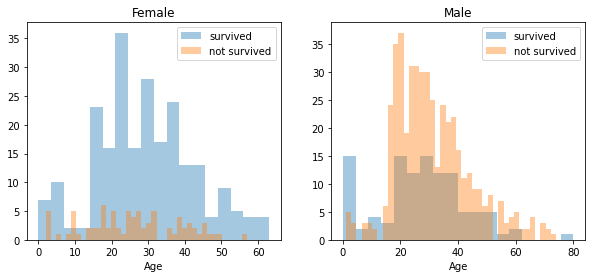

In [28]:
survived = 'survived'
not_survived = 'not survived'
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10, 4))
women = train_df[train_df['Sex']=='female']
men = train_df[train_df['Sex']=='male']
ax = sns.distplot(women[women['Survived']==1].Age.dropna(), bins=18, label = survived, ax = axes[0], kde =False)
ax = sns.distplot(women[women['Survived']==0].Age.dropna(), bins=40, label = not_survived, ax = axes[0], kde =False)
ax.legend()
ax.set_title('Female')
ax = sns.distplot(men[men['Survived']==1].Age.dropna(), bins=18, label = survived, ax = axes[1], kde = False)
ax = sns.distplot(men[men['Survived']==0].Age.dropna(), bins=40, label = not_survived, ax = axes[1], kde = False)
ax.legend()
ax= ax.set_title('Male')

You can see that men have a high probability of survival when they are between 18 and 30 years old, which is also a little bit true for women but not fully. For women the survival chances are higher between 14 and 40.
For men the probability of survival is very low between the age of 5 and 18, but that isn’t true for women. Another thing to note is that infants also have a little bit higher probability of survival.

In [29]:
train_df['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

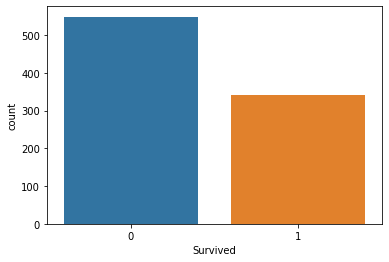

In [30]:
sns.countplot(data=train_df,x='Survived')

<AxesSubplot:xlabel='Sex', ylabel='count'>

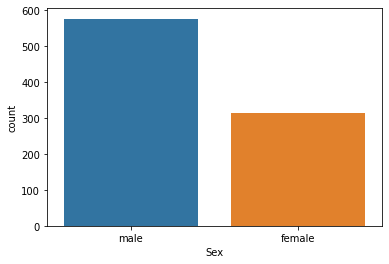

In [31]:
sns.countplot(data=train_df,x='Sex')

<AxesSubplot:xlabel='Sex', ylabel='Age'>

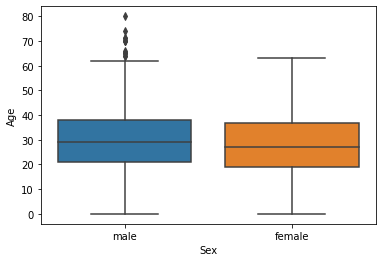

In [32]:
sns.boxplot(data=train_df,x='Sex',y='Age')

In [33]:
# sns.boxplot(data=train_df,x='Sex',y='Survived')

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

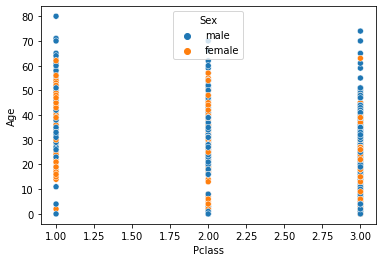

In [34]:
sns.scatterplot(data=train_df, x='Pclass', y='Age', hue='Sex')

<AxesSubplot:xlabel='Pclass', ylabel='count'>

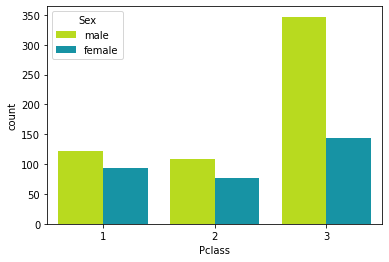

In [35]:
sns.countplot(data=train_df,x='Pclass',hue="Sex",palette='nipy_spectral_r')

<AxesSubplot:xlabel='Embarked', ylabel='count'>

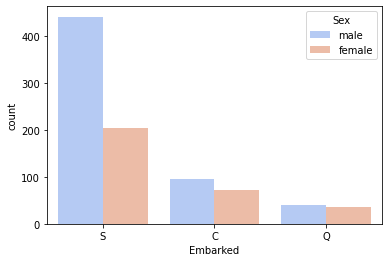

In [36]:
sns.countplot(data=train_df,x='Embarked',hue="Sex",palette='coolwarm')

/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


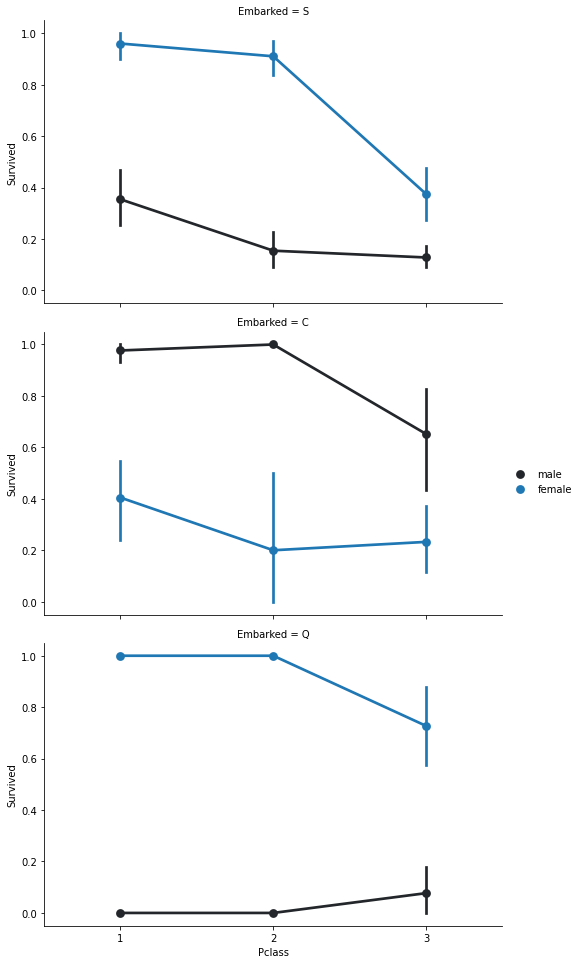

In [37]:
FacetGrid = sns.FacetGrid(train_df, row='Embarked', size=4.5, aspect=1.6)
FacetGrid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', palette=None,  order=None, hue_order=None )
FacetGrid.add_legend()

Embarked seems to be correlated with survival, depending on the gender.
Women on port Q and on port S have a higher chance of survival. The inverse is true, if they are at port C. Men have a high survival probability if they are on port C, but a low probability if they are on port Q or S.
Pclass also seems to be correlated with survival.

 **SibSp and Parch:**
 
SibSp and Parch would make more sense as a combined feature, that shows the total number of relatives, a person has on the Titanic. I will create it below and also a feature that sows if someone is not alone.

In [38]:
data = [train_df, test_df]
for dataset in data:
    dataset['relatives'] = dataset['SibSp'] + dataset['Parch']
    dataset.loc[dataset['relatives'] > 0, 'not_alone'] = 0
    dataset.loc[dataset['relatives'] == 0, 'not_alone'] = 1
    dataset['not_alone'] = dataset['not_alone'].astype(int)
train_df['not_alone'].value_counts()

1    537
0    354
Name: not_alone, dtype: int64

In [39]:
# train_df = train_df.drop(['Parch'], axis=1)
# train_df = train_df.drop(['SibSp'], axis=1)
train_df = train_df.drop(['relatives'], axis=1)


# test_df = test_df.drop(['Parch'], axis=1)
# test_df = test_df.drop(['SibSp'], axis=1)
test_df = test_df.drop(['relatives'], axis=1)

<AxesSubplot:xlabel='not_alone', ylabel='count'>

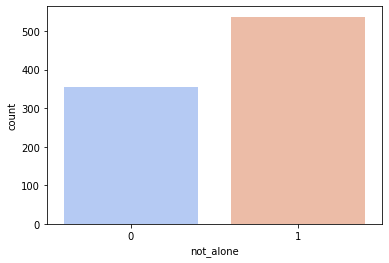

In [40]:
sns.countplot(data=train_df,x='not_alone',palette='coolwarm')

<AxesSubplot:xlabel='not_alone', ylabel='count'>

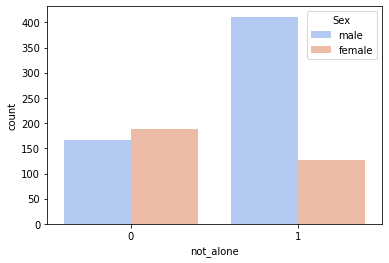

In [41]:
sns.countplot(data=train_df,x='not_alone',hue="Sex",palette='coolwarm')

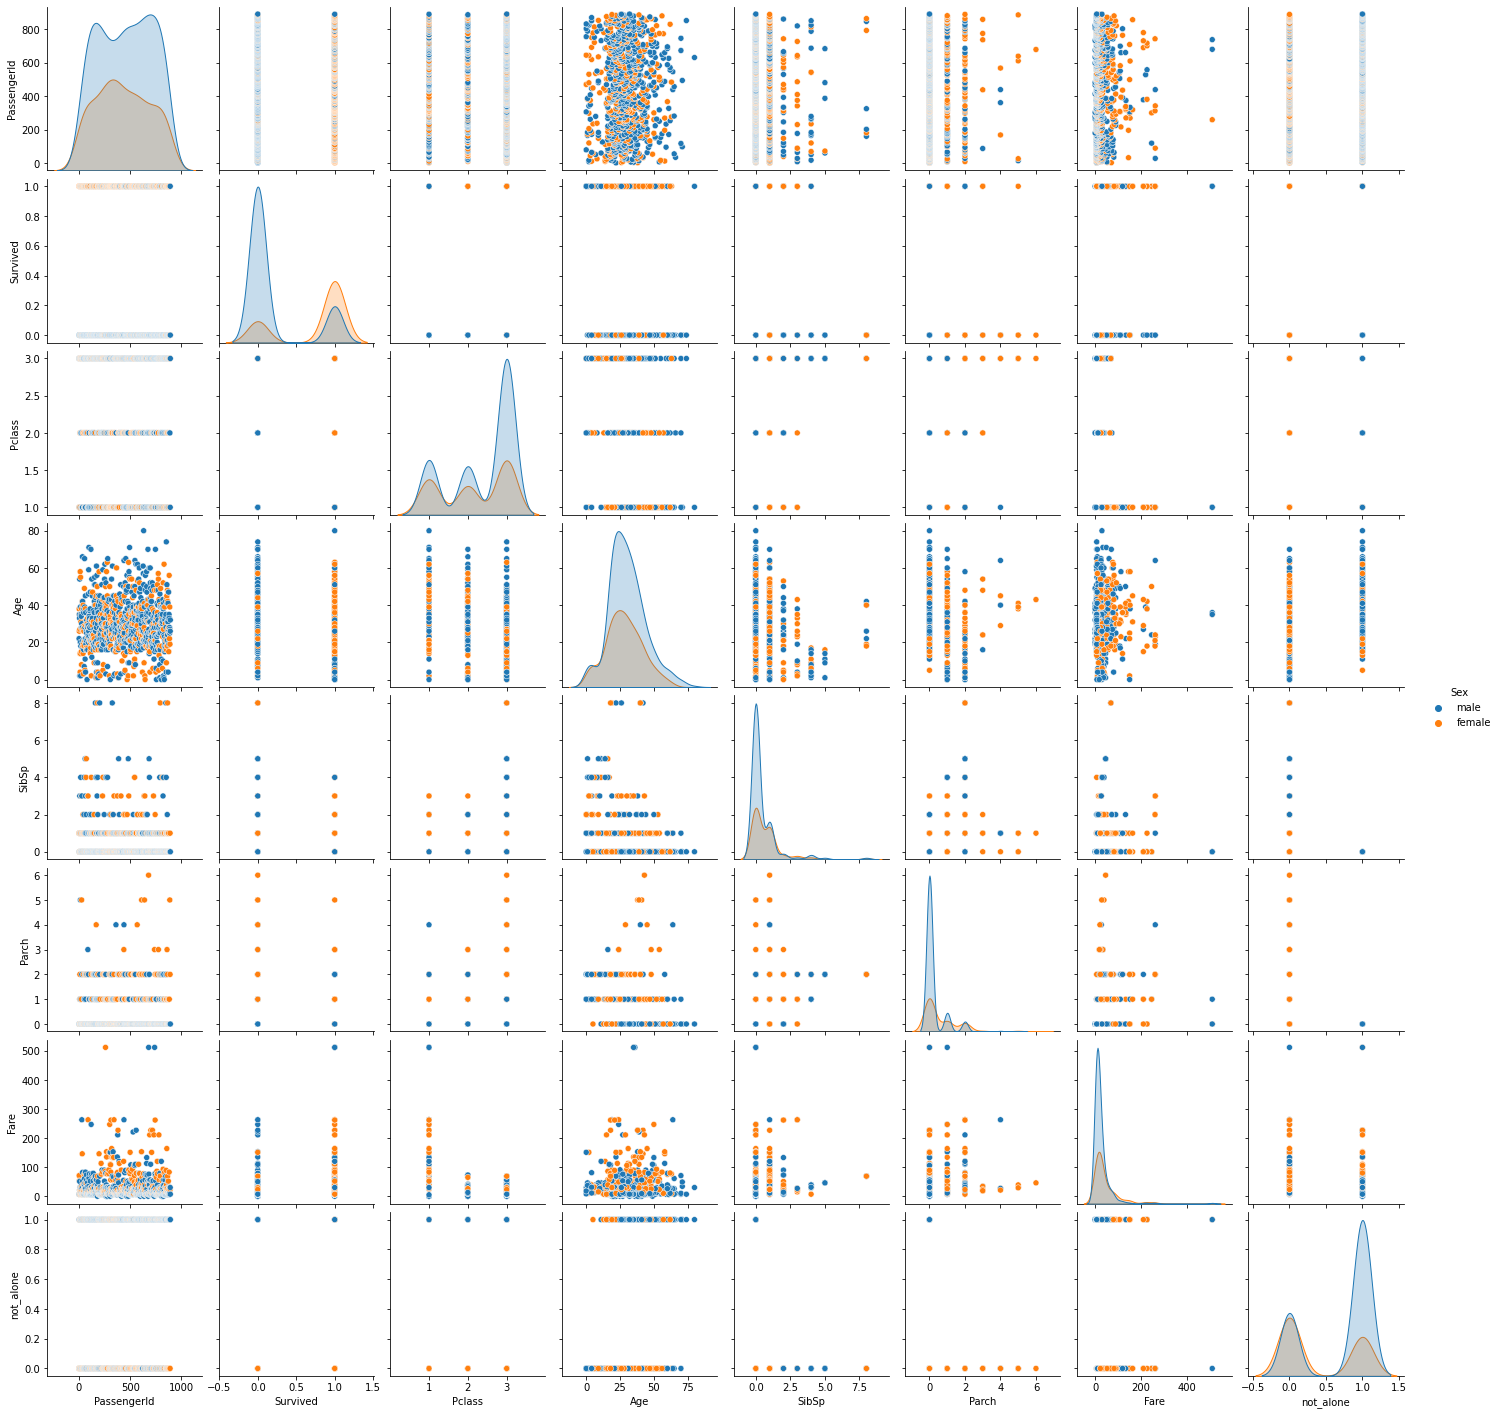

In [42]:
sns.pairplot(train_df,hue='Sex')

<AxesSubplot:>

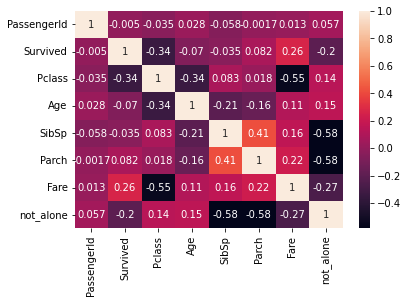

In [43]:
sns.heatmap(train_df.corr(), annot=True)

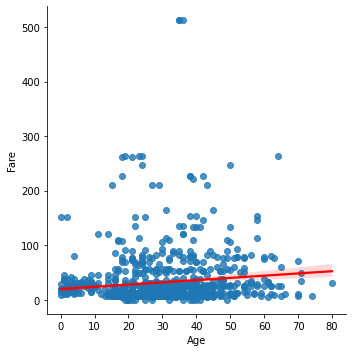

In [44]:
sns.lmplot(x='Age', y='Fare', data=train_df, line_kws={'color':'red'})

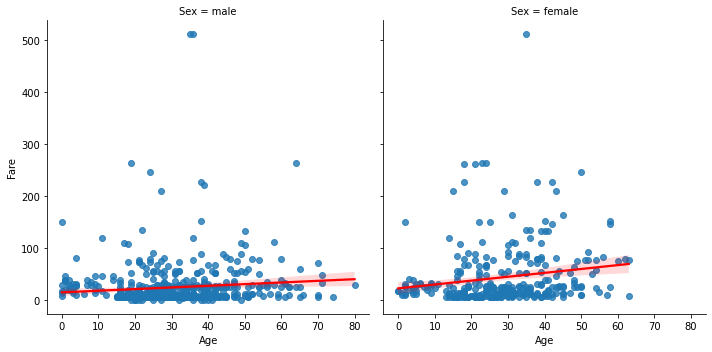

In [45]:
sns.lmplot(x='Age',
           y='Fare',
           data=train_df,
           line_kws={'color':'red'},
           col='Sex'
          )

In [46]:
# train_df

In [47]:
import plotly.express as px
fig = px.scatter_3d(train_df, x='Age', y='Pclass', z='Survived',color='Pclass',opacity=0.7)
fig.show()


In [48]:
# train_df['Sex'] = train_df['Sex'].map({'male': 0,'female': 1})


#### We will use the Name feature to extract the Titles from the Name

In [49]:
train_df['Title'] = train_df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = train_df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)


In [50]:
train_df['Title'].value_counts()

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Col           2
Mlle          2
Jonkheer      1
Mme           1
Countess      1
Sir           1
Lady          1
Capt          1
Don           1
Ms            1
Name: Title, dtype: int64

In [51]:
data = [train_df, test_df]

for dataset in data:
    # replace titles with a more common title or as Rare
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr',\
                                            'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

train_df = train_df.drop(['Name'], axis=1)
test_df = test_df.drop(['Name'], axis=1)

In [52]:
# genders = {"male": 0, "female": 1}
# data = [train_df, test_df]

# for dataset in data:
#     dataset['Sex'] = dataset['Sex'].map(genders)

In [53]:
train_df['Ticket'].describe()


count          891
unique         681
top       CA. 2343
freq             7
Name: Ticket, dtype: object

> Ticket attribute has 681 unique tickets, it will be a bit tricky to convert them into useful categories. So we will drop it from the dataset.

In [54]:
train_df.drop(['Ticket'], axis=1, inplace=True)
test_df.drop(['Ticket'], axis=1, inplace=True)

In [55]:
y = train_df['Survived'].apply(int)
train_df.drop(['Survived'], axis=1,inplace=True)


In [56]:
train_df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,not_alone,Title
0,1,3,male,22,1,0,7,S,0,Mr
1,2,1,female,38,1,0,71,C,0,Mrs
2,3,3,female,26,0,0,7,S,1,Miss
3,4,1,female,35,1,0,53,S,0,Mrs
4,5,3,male,35,0,0,8,S,1,Mr
...,...,...,...,...,...,...,...,...,...,...
886,887,2,male,27,0,0,13,S,1,Rare
887,888,1,female,19,0,0,30,S,1,Miss
888,889,3,female,26,1,2,23,S,0,Miss
889,890,1,male,26,0,0,30,C,1,Mr


In [57]:
test_df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,not_alone,Title
0,892,3,male,34,0,0,7,Q,1,Mr
1,893,3,female,47,1,0,7,S,0,Mrs
2,894,2,male,62,0,0,9,Q,1,Miss
3,895,3,male,27,0,0,8,S,1,Mrs
4,896,3,female,22,1,1,12,S,0,Mr
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,male,24,0,0,8,S,1,Mr
414,1306,1,female,39,0,0,108,C,1,Mr
415,1307,3,male,38,0,0,7,S,1,Mrs
416,1308,3,male,28,0,0,8,S,1,Mrs


#### Merging the test and train dataset

In [58]:
all_df = pd.concat([train_df , test_df], axis=0)
all_df.index = np.arange(1, len(all_df) + 1)
all_df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,not_alone,Title
1,1,3,male,22,1,0,7,S,0,Mr
2,2,1,female,38,1,0,71,C,0,Mrs
3,3,3,female,26,0,0,7,S,1,Miss
4,4,1,female,35,1,0,53,S,0,Mrs
5,5,3,male,35,0,0,8,S,1,Mr
...,...,...,...,...,...,...,...,...,...,...
1305,1305,3,male,24,0,0,8,S,1,Mr
1306,1306,1,female,39,0,0,108,C,1,Mr
1307,1307,3,male,38,0,0,7,S,1,Mrs
1308,1308,3,male,28,0,0,8,S,1,Mrs


In [59]:
all_df.drop('PassengerId', axis=1, inplace=True)
all_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,not_alone,Title
1,3,male,22,1,0,7,S,0,Mr
2,1,female,38,1,0,71,C,0,Mrs
3,3,female,26,0,0,7,S,1,Miss
4,1,female,35,1,0,53,S,0,Mrs
5,3,male,35,0,0,8,S,1,Mr
...,...,...,...,...,...,...,...,...,...
1305,3,male,24,0,0,8,S,1,Mr
1306,1,female,39,0,0,108,C,1,Mr
1307,3,male,38,0,0,7,S,1,Mrs
1308,3,male,28,0,0,8,S,1,Mrs


In [60]:
all_df.isnull().sum()

Pclass       0
Sex          0
Age          0
SibSp        0
Parch        0
Fare         0
Embarked     0
not_alone    0
Title        0
dtype: int64

In [61]:
# num_df= all_df.select_dtypes(exclude='object')
# obj_df= all_df.select_dtypes(include='object')

#### Dealing with the categorical data and  numerical values

In [62]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 1 to 1309
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Pclass     1309 non-null   int64 
 1   Sex        1309 non-null   object
 2   Age        1309 non-null   int64 
 3   SibSp      1309 non-null   int64 
 4   Parch      1309 non-null   int64 
 5   Fare       1309 non-null   int64 
 6   Embarked   1309 non-null   object
 7   not_alone  1309 non-null   int64 
 8   Title      1309 non-null   object
dtypes: int64(6), object(3)
memory usage: 102.3+ KB


In [63]:
all_df['Pclass'] = all_df['Pclass'].apply(str)
all_df['not_alone'] = all_df['not_alone'].apply(str)

# all_df['Parch'] = all_df['Parch'].apply(str)
# all_df['SibSp'] = all_df['SibSp'].apply(str)


In [64]:
num_df=all_df[['Age','Fare','SibSp', 'Parch']]
obj_df=all_df[['Pclass', 'Sex', 'Embarked','not_alone']]
# obj_df=all_df[["Pclass", "Sex", "SibSp", "Parch",'Embarked','not_alone']]

In [65]:
num_df

,Age,Fare,SibSp,Parch
1,22,7,1,0
2,38,71,1,0
3,26,7,0,0
4,35,53,1,0
5,35,8,0,0
...,...,...,...,...
1305,24,8,0,0
1306,39,108,0,0
1307,38,7,0,0
1308,28,8,0,0


In [66]:
obj_df

,Pclass,Sex,Embarked,not_alone
1,3,male,S,0
2,1,female,C,0
3,3,female,S,1
4,1,female,S,0
5,3,male,S,1
...,...,...,...,...
1305,3,male,S,1
1306,1,female,C,1
1307,3,male,S,1
1308,3,male,S,1


In [67]:
obj_df= pd.get_dummies(obj_df, drop_first=True)
obj_df

,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,not_alone_1
1,0,1,1,0,1,0
2,0,0,0,0,0,0
3,0,1,0,0,1,1
4,0,0,0,0,1,0
5,0,1,1,0,1,1
...,...,...,...,...,...,...
1305,0,1,1,0,1,1
1306,0,0,0,0,0,1
1307,0,1,1,0,1,1
1308,0,1,1,0,1,1


In [68]:
train_num_df = num_df.iloc[:891, :]
train_obj_df = obj_df.iloc[:891, :]


In [69]:
test_num_df = num_df.iloc[891:, :]
test_obj_df = obj_df.iloc[891:, :]

In [70]:
train_df_new = pd.concat([train_num_df, train_obj_df], axis=1)
test_df_new = pd.concat([test_num_df, test_obj_df], axis=1)
train_df_new.reset_index(drop=True, inplace=True)
train_df_new['Survived']=y

In [71]:
train_df_new.head()

,Age,Fare,SibSp,Parch,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,not_alone_1,Survived
0,22,7,1,0,0,1,1,0,1,0,0
1,38,71,1,0,0,0,0,0,0,0,1
2,26,7,0,0,0,1,0,0,1,1,1
3,35,53,1,0,0,0,0,0,1,0,1
4,35,8,0,0,0,1,1,0,1,1,0


In [72]:
train_df_new.isnull().sum()

Age            0
Fare           0
SibSp          0
Parch          0
Pclass_2       0
Pclass_3       0
Sex_male       0
Embarked_Q     0
Embarked_S     0
not_alone_1    0
Survived       0
dtype: int64

In [73]:
test_df_new.head()

,Age,Fare,SibSp,Parch,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,not_alone_1
892,34,7,0,0,0,1,1,1,0,1
893,47,7,1,0,0,1,0,0,1,0
894,62,9,0,0,1,0,1,1,0,1
895,27,8,0,0,0,1,1,0,1,1
896,22,12,1,1,0,1,0,0,1,0


In [74]:
test_df_new.isnull().sum()

Age            0
Fare           0
SibSp          0
Parch          0
Pclass_2       0
Pclass_3       0
Sex_male       0
Embarked_Q     0
Embarked_S     0
not_alone_1    0
dtype: int64

In [75]:
train_df_new.to_csv('train_df_cleaned.csv')
test_df_new.to_csv('test_df_cleaned.csv')

### Data Scaling

#### we can see that the features have widely different ranges, that we will need to convert into roughly the same scale

In [76]:
from sklearn.preprocessing import StandardScaler


In [77]:
names = train_num_df.columns

scaler= StandardScaler()
scaler.fit(train_num_df)
train_num_df= scaler.transform(train_num_df)
test_num_df= scaler.transform(test_num_df)

train_num_df = pd.DataFrame(train_num_df, columns= names)
train_num_df.index = np.arange(1, len(train_num_df) + 1)

test_num_df = pd.DataFrame(test_num_df, columns= names)
test_num_df.index = np.arange(892, 892 + len(test_num_df))

In [78]:
train_scaled_df = pd.concat([train_num_df, train_obj_df], axis=1)
test_scaled_df = pd.concat([test_num_df, test_obj_df], axis=1)
train_scaled_df

,Age,Fare,SibSp,Parch,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,not_alone_1
1,-0.550117,-0.498948,0.432793,-0.473674,0,1,1,0,1,0
2,0.629911,0.789405,0.432793,-0.473674,0,0,0,0,0,0
3,-0.255110,-0.498948,-0.474545,-0.473674,0,1,0,0,1,1
4,0.408656,0.427056,0.432793,-0.473674,0,0,0,0,1,0
5,0.408656,-0.478817,-0.474545,-0.473674,0,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...
887,-0.181358,-0.378164,-0.474545,-0.473674,1,0,1,0,1,1
888,-0.771372,-0.035946,-0.474545,-0.473674,0,0,0,0,1,1
889,-0.255110,-0.176859,0.432793,2.008933,0,1,0,0,1,0
890,-0.255110,-0.035946,-0.474545,-0.473674,0,0,1,0,0,1


In [79]:
train_scaled_df

,Age,Fare,SibSp,Parch,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,not_alone_1
1,-0.550117,-0.498948,0.432793,-0.473674,0,1,1,0,1,0
2,0.629911,0.789405,0.432793,-0.473674,0,0,0,0,0,0
3,-0.255110,-0.498948,-0.474545,-0.473674,0,1,0,0,1,1
4,0.408656,0.427056,0.432793,-0.473674,0,0,0,0,1,0
5,0.408656,-0.478817,-0.474545,-0.473674,0,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...
887,-0.181358,-0.378164,-0.474545,-0.473674,1,0,1,0,1,1
888,-0.771372,-0.035946,-0.474545,-0.473674,0,0,0,0,1,1
889,-0.255110,-0.176859,0.432793,2.008933,0,1,0,0,1,0
890,-0.255110,-0.035946,-0.474545,-0.473674,0,0,1,0,0,1


##  Logistic Regression Model

In [80]:
from sklearn.linear_model import LogisticRegression
log_model= LogisticRegression()
log_model.fit(train_scaled_df, y)

LogisticRegression()

#### Model Coeficient

In [81]:
log_model.coef_


array([[-0.48423388,  0.14467641, -0.55266548, -0.19402988, -0.76038071,
        -1.8640331 , -2.52479081,  0.007356  , -0.34752057, -0.71179008]])

In [82]:
y_pred= log_model.predict(test_scaled_df)


#### Evaluating the Model

In [83]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix

In [84]:
y_test=submit['Survived']

In [85]:
accuracy_score(y_test, y_pred)

0.937799043062201

In [86]:
confusion_matrix(y_test, y_pred)

array([[250,  16],
       [ 10, 142]])

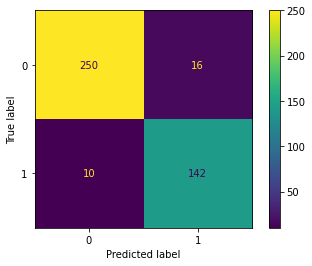

In [87]:
plot_confusion_matrix(log_model, test_scaled_df, y_test)

In [88]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       266
           1       0.90      0.93      0.92       152

    accuracy                           0.94       418
   macro avg       0.93      0.94      0.93       418
weighted avg       0.94      0.94      0.94       418



### Evaluating Curves and AUC

In [89]:
from sklearn.metrics import precision_recall_curve, plot_precision_recall_curve, plot_roc_curve

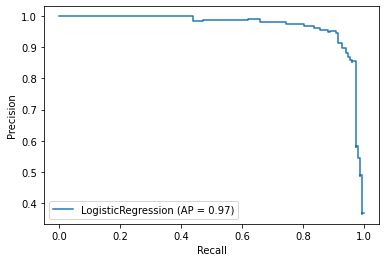

In [90]:
plot_precision_recall_curve(log_model, test_scaled_df, y_test)

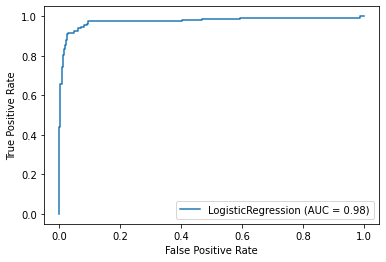

In [91]:
plot_roc_curve(log_model, test_scaled_df, y_test)

In [92]:
# submission = pd.DataFrame()
# submission['PassengerId'] = test_scaled_df.index
# submission['Survived'] = y_pred
# submission.to_csv('submission.csv',index=False)